In [16]:
import pandas as pd

# 改成你的檔名
file_path = "../data/raw/CityC_Sapporo.csv"

df = pd.read_csv(file_path)

print("資料集總筆數：", len(df))
print("欄位名稱：", list(df.columns))
print("使用者數量 uid：", df["uid"].nunique())
print("天數 d：", df["d"].nunique())
print("時段 t：", df["t"].nunique())
print("X座標格網數：", df["x"].nunique())
print("Y座標格網數：", df["y"].nunique())
print("總格網數 x-y：", df[["x", "y"]].drop_duplicates().shape[0])

print("\n資料前五筆：")
display(df.head())

資料集總筆數： 18456528
欄位名稱： ['uid', 'd', 't', 'x', 'y']
使用者數量 uid： 20000
天數 d： 75
時段 t： 48
X座標格網數： 194
Y座標格網數： 201
總格網數 x-y： 9209

資料前五筆：


,uid,d,t,x,y
0,0,5,15,28,157
1,0,5,16,28,158
2,0,5,17,28,157
3,0,5,18,29,158
4,0,5,19,27,157


In [17]:
summary_table = pd.DataFrame({
    "項目": [
        "資料總筆數",
        "使用者數量",
        "天數數量",
        "時段數量",
        "X座標格網數",
        "Y座標格網數",
        "總格網數",
        "d最小值",
        "d最大值",
        "t最小值",
        "t最大值"
    ],
    "數值": [
        len(df),
        df["uid"].nunique(),
        df["d"].nunique(),
        df["t"].nunique(),
        df["x"].nunique(),
        df["y"].nunique(),
        df[["x", "y"]].drop_duplicates().shape[0],
        df["d"].min(),
        df["d"].max(),
        df["t"].min(),
        df["t"].max()
    ]
})

display(summary_table)

,項目,數值
0,資料總筆數,18456528
1,使用者數量,20000
2,天數數量,75
3,時段數量,48
4,X座標格網數,194
5,Y座標格網數,201
6,總格網數,9209
7,d最小值,0
8,d最大值,74
9,t最小值,0


In [18]:
sample_table = df.head(5).copy()

display(sample_table)

,uid,d,t,x,y
0,0,5,15,28,157
1,0,5,16,28,158
2,0,5,17,28,157
3,0,5,18,29,158
4,0,5,19,27,157


In [19]:
daily_table = (
    df.groupby("d")
      .size()
      .reset_index(name="record_count")
)

display(daily_table.head(10))

,d,record_count
0,0,203772
1,1,207406
2,2,253588
3,3,250162
4,4,255523
5,5,261783
6,6,236365
7,7,211717
8,8,200903
9,9,262683


In [20]:
time_table = (
    df.groupby("t")
      .size()
      .reset_index(name="record_count")
)

display(time_table.head(10))

,t,record_count
0,0,154415
1,1,159203
2,2,150856
3,3,143994
4,4,139315
5,5,134933
6,6,133160
7,7,132605
8,8,137113
9,9,145680


In [21]:
grid_table = (
    df.groupby(["x", "y"])
      .size()
      .reset_index(name="record_count")
      .sort_values("record_count", ascending=False)
)

display(grid_table.head(10))

,x,y,record_count
9208,999,999,449308
2579,25,153,159523
2697,26,153,159275
2696,26,152,113729
2466,24,153,108643
2578,25,152,92175
2580,25,154,65250
2464,24,151,63777
2819,27,153,58231
2577,25,151,55238


In [22]:
import pandas as pd

# 改成你們實際的檔案
df_parks = pd.read_csv("../data/parking lots/sapporo_synthetic_parking_lots.csv")

summary = pd.DataFrame({
    "項目": [
        "停車場數量",
        "平均容量",
        "最大容量",
        "最小容量"
    ],
    "數值": [
        len(df_parks),
        df_parks["capacity"].mean() if "capacity" in df_parks else "N/A",
        df_parks["capacity"].max() if "capacity" in df_parks else "N/A",
        df_parks["capacity"].min() if "capacity" in df_parks else "N/A"
    ]
})

display(summary)
display(df_parks.head(10))

,項目,數值
0,停車場數量,3924.000000
1,平均容量,44.961519
2,最大容量,967.000000
3,最小容量,0.000000


,park_id,grid_x,grid_y,park_x,park_y,park_lat,park_lng,urban_score,is_city,capacity,type,access
0,node/1669817019,24,150,24.396238,150.327510,43.067234,141.347329,2.288744,1,23,surface,yes
1,node/1682560396,32,149,32.319706,148.815222,43.106533,141.339452,0.383169,1,351,multi-storey,yes
2,node/1971133821,29,183,29.419872,182.636943,43.094295,141.510608,0.281154,1,40,surface,yes
3,node/2003840718,24,151,24.087080,150.778832,43.065726,141.349621,3.729435,1,225,multi-storey,yes
4,node/2003844199,24,150,24.135954,150.260492,43.065936,141.346998,2.288744,1,392,multi-storey,yes
5,node/2003846802,24,150,24.121320,150.114067,43.065853,141.346258,2.288744,1,600,surface,yes
6,node/2021939474,36,130,36.388104,129.643842,43.125526,141.242366,0.491483,1,29,surface,yes
7,node/2039276545,25,151,24.626982,151.480253,43.068456,141.353153,3.184561,1,35,surface,yes
8,node/2057917874,23,149,23.316766,148.551524,43.061752,141.338377,0.491728,1,78,multi-storey,yes
9,node/2097530216,23,151,22.807086,151.125686,43.059384,141.351412,1.326877,1,29,multi-storey,yes


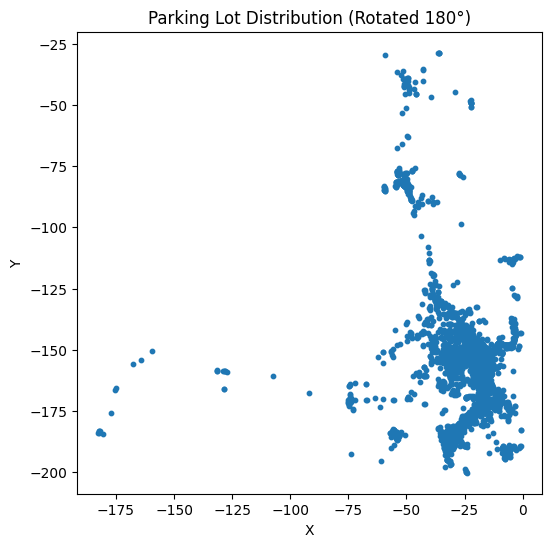

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(
    -df_parks["park_x"],   # X反轉
    -df_parks["park_y"],   # Y反轉
    s=10
)

plt.title("Parking Lot Distribution (Rotated 180°)")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [10]:
import sys
import os

# 將當前目錄加入搜尋路徑
sys.path.append(os.path.abspath('..'))

In [16]:
from src.parks_create import *
from src.parks_routing import *
from src.geo.grid_to_latlng import GridLatLngMapper
from src.ConvLSTM import *
from src.preprocess import *

# 設定
START_DATE = "2019-09-15"
PARQUET_PATH = "../data/processed/sapporo_density.parquet"
CONVLSTM_PATH = "../models/convlstm_sapporo.pkl"

anchors = [
    {"x": 24, "y": 151, "lat": 43.0691833, "lng": 141.3514707},
    {"x": 24, "y": 148, "lat": 43.0794037, "lng": 141.3422559},
    {"x": 26, "y": 153, "lat": 43.0579859, "lng": 141.3540211},
    {"x": 52, "y": 81,  "lat": 43.1982317, "lng": 140.9940363},
    {"x": 50, "y": 41,  "lat": 43.1880641, "lng": 140.7945541},
    {"x": 182, "y": 186, "lat": 43.8536095, "lng": 141.5234881},
]
mapper = GridLatLngMapper(anchors)

# 載入資料與模型
df_raw = prepare_base_df(PARQUET_PATH)
model, cfg = load_convlstm_embed(CONVLSTM_PATH)

df_feat = add_lags_and_rollings(df_raw.copy(), seq_len=cfg["seq_len"], start_date=START_DATE)
df_feat = df_feat.dropna(subset=[f"lag_{k}" for k in range(1, cfg["seq_len"]+1)]).copy()

# 預測人流
df_pred = make_df_pred_convlstm_embed(df_feat, model, cfg)

# 產生停車場資料
south, west, north, east = 42.9, 140.7, 43.9, 141.6
df_parks, df_with_a, df_prob = create_poi_parking(
    df_pred, south, west, north, east,
    mapper, START_DATE, refetch=False
)

print("df_prob shape:", df_prob.shape)
print(df_prob.head())

ImportError: cannot import name 'FileLike' from 'torch.types' (d:\projects\2025_japan_people_flow\venv312\Lib\site-packages\torch\types.py)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

SLOT_MIN = 30

# ===== 圖A：代表性停車場 平日 vs 假日 p_avail 24小時輪廓 =====

def plot_pavail_weekday_vs_weekend(df_prob, df_parks, n_parks=3, seed=42):
    """
    隨機選 n_parks 個停車場，畫平日 vs 假日的平均 p_avail 輪廓
    """
    # 加 weekday 欄位
    df = df_prob.copy()
    df["is_weekend"] = (df["d"].astype(int) % 7).isin([5, 6]).astype(int)

    # 選有足夠資料的停車場
    park_counts = df.groupby("park_id")["d"].nunique()
    valid_parks = park_counts[park_counts >= 5].index.tolist()

    rng = np.random.default_rng(seed)
    selected = rng.choice(valid_parks, size=min(n_parks, len(valid_parks)), replace=False)

    fig, axes = plt.subplots(1, len(selected), figsize=(6 * len(selected), 4), sharey=True)
    if len(selected) == 1:
        axes = [axes]

    for ax, park_id in zip(axes, selected):
        sub = df[df["park_id"] == park_id]

        wd = sub[sub["is_weekend"] == 0].groupby("t")["p_avail"].mean()
        we = sub[sub["is_weekend"] == 1].groupby("t")["p_avail"].mean()

        t_vals = sorted(set(wd.index) | set(we.index))
        tick_pos = range(0, 48, 4)
        tick_labels = [f"{i//2:02d}:00" for i in tick_pos]

        if len(wd) > 0:
            ax.plot(wd.reindex(t_vals), color="#1565c0", label="Weekday Avg", linewidth=1.8)
        if len(we) > 0:
            ax.plot(we.reindex(t_vals), color="#e53935", label="Weekend Avg", linewidth=1.8)

        ax.set_xticks(list(tick_pos))
        ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)
        ax.set_title(f"Park: {str(park_id)[:12]}", fontsize=10)
        ax.set_xlabel("Time of Day")
        ax.set_ylabel("P(available)")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle("Parking Availability: Weekday vs Weekend (Selected Parks)", fontsize=12)
    plt.tight_layout()
    plt.savefig("pavail_weekday_vs_weekend.png", dpi=150, bbox_inches="tight")
    plt.show()


# ===== 圖B：市區 vs 郊區 平均 p_avail 全日輪廓 =====

def plot_pavail_city_vs_suburb(df_prob, df_parks):
    """
    依 is_city 分組，畫市區 vs 郊區的平均 p_avail 全日輪廓
    """
    df = df_prob.merge(
        df_parks[["park_id", "is_city"]],
        on="park_id", how="left"
    )
    df = df.dropna(subset=["is_city"])

    city  = df[df["is_city"] == 1].groupby("t")["p_avail"].mean()
    suburb = df[df["is_city"] == 0].groupby("t")["p_avail"].mean()

    t_vals = sorted(set(city.index) | set(suburb.index))
    tick_pos = range(0, 48, 4)
    tick_labels = [f"{i//2:02d}:02d" for i in tick_pos]
    tick_labels = [f"{i//2:02d}:00" for i in tick_pos]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(city.reindex(t_vals),   color="#e53935", label="Urban Parking",   linewidth=2)
    ax.plot(suburb.reindex(t_vals), color="#1565c0", label="Suburban Parking", linewidth=2)

    ax.set_xticks(list(tick_pos))
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=9)
    ax.set_title("Average Parking Availability: Urban vs Suburban", fontsize=12)
    ax.set_xlabel("Time of Day")
    ax.set_ylabel("P(available)")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("pavail_city_vs_suburb.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 印統計數字
    print(f"Urban   avg p_avail: {df[df['is_city']==1]['p_avail'].mean():.4f}")
    print(f"Suburban avg p_avail: {df[df['is_city']==0]['p_avail'].mean():.4f}")


# ===== 執行 =====
plot_pavail_weekday_vs_weekend(df_prob, df_parks, n_parks=3)
plot_pavail_city_vs_suburb(df_prob, df_parks)

NameError: name 'df_prob' is not defined